
# Module 22: XGBoost (Practice Notebook)

### Instructions for Students
- This is a **practice notebook**.
- Complete all **TODO** sections.
- Read the markdown explanations carefully.
- Do not skip evaluation and reflection questions.

Dataset used here is **California Housing (Regression)**.



## 1. Import Required Libraries


In [1]:
# TODO: Import necessary libraries

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor


## 2. Load Dataset (California Housing)


In [6]:
# TODO: Load dataset

from sklearn.datasets import fetch_openml

data = fetch_openml(name="  ", version=1, as_frame=True)
X = data.data
y = data.target
X["ocean_proximity"]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND



## 3. Train-Test Split


In [7]:
# TODO: Perform train-test split
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


## 4. Baseline XGBoost Regressor


In [26]:
# TODO: Train baseline model
model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    colsample_bytree=0.8,
    subsample=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
)


## 5. Evaluate Baseline Model


In [27]:
# TODO: Evaluate baseline
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)


mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
print('RMSE: ', rmse)
print('R2 : ', r2)
print()

RMSE:  56109.67317673487
R2 :  0.7620728015899658




## 6. Hyperparameter Tuning with GridSearchCV


In [28]:
# TODO: Define parameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}




### Base Model for Grid Search


In [32]:
# TODO: Base model

base_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    colsample_bytree=0.8,
    random_state=42
)


### Run GridSearchCV


In [33]:
# TODO: Run GridSearchCV
grid = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring = "neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Best CV Accuracy: -2251844172.8



## 7. Evaluate Tuned Model


RMSE:  46923.46926645556
R2 :  0.833601713180542



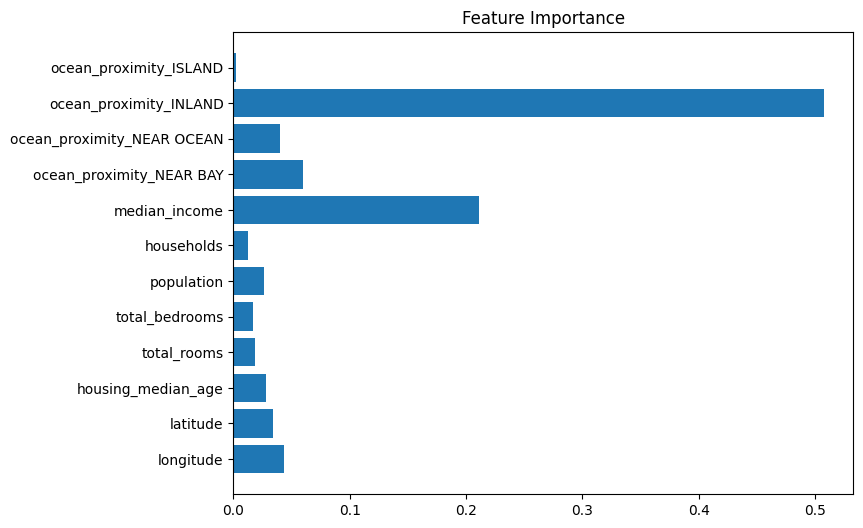

In [35]:
# TODO: Evaluate tuned model
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_tuned)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tuned)
print('RMSE: ', rmse)
print('R2 : ', r2)
print()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(X.columns, best_model.feature_importances_)
plt.title("Feature Importance")
plt.show()


## 8. Reflection Questions

1. Did GridSearch improve performance?
2. Which parameter had the biggest effect?
3. What happens if learning_rate is too high?
4. Would you deploy this model? Why?
